# Sobremuestreo y Submuestreo
## Machine Learning — Sesión Práctica

Este notebook ilustra de manera práctica los conceptos de **submuestreo** (undersampling) y **sobremuestreo** (oversampling) para el manejo de **desbalance de clases** en problemas de clasificación.


In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

COLORS = {'mayoritaria': '#4ECDC4', 'minoritaria': '#FF6B6B',
           'sintetico': '#FFE66D', 'fondo': '#4d4b4c', 'acento': '#00e1ff'}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. El problema del desbalance de clases

Creamos un dataset sintético desbalanceado para ilustrar el problema.

In [ ]:
# @title
# Crear dataset desbalanceado (ratio 10:1)
X, y = make_classification(
    n_samples=1100, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.91, 0.09],
    flip_y=0.02, random_state=42
)

print(f'Total de muestras: {len(y)}')
print(f'Clase 0 (mayoritaria): {np.sum(y == 0)} ({np.mean(y == 0)*100:.1f}%)')
print(f'Clase 1 (minoritaria): {np.sum(y == 1)} ({np.mean(y == 1)*100:.1f}%)')
print(f'Ratio: {np.sum(y == 0) / np.sum(y == 1):.1f}:1')

Total de muestras: 1100
Clase 0 (mayoritaria): 990 (90.0%)
Clase 1 (minoritaria): 110 (10.0%)
Ratio: 9.0:1


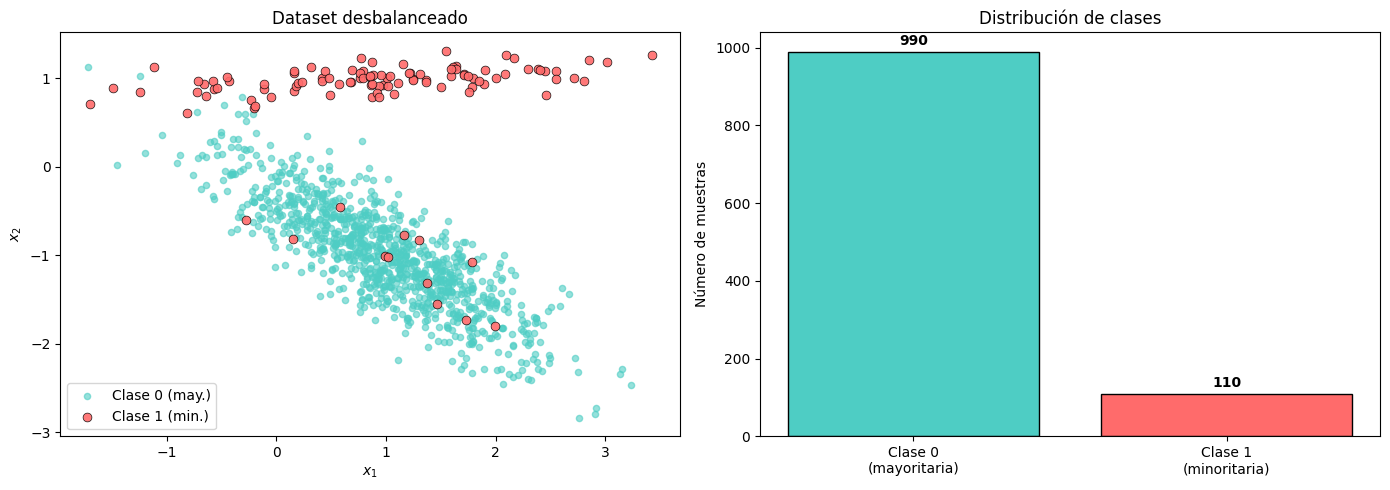

In [ ]:
# @title
# Visualización del desbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(X[y == 0, 0], X[y == 0, 1], c=COLORS['mayoritaria'], label='Clase 0 (may.)', alpha=0.6, s=20)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c=COLORS['minoritaria'], label='Clase 1 (min.)', alpha=0.9, s=40, edgecolors='k', linewidths=0.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Dataset desbalanceado')
ax.legend()

# Barras
ax = axes[1]
counts = [np.sum(y == 0), np.sum(y == 1)]
bars = ax.bar(['Clase 0\n(mayoritaria)', 'Clase 1\n(minoritaria)'], counts,
              color=[COLORS['mayoritaria'], COLORS['minoritaria']], edgecolor='k')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(count),
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Número de muestras')
ax.set_title('Distribución de clases')

plt.tight_layout()
plt.show()

### 1.1. ¿Por qué el accuracy engaña?

Un modelo que predice siempre la clase mayoritaria obtiene un accuracy alto pero no detecta la clase de interés.

In [ ]:
# Modelo que predice siempre clase 0
y_pred_naive = np.zeros_like(y)

print('=== Modelo ingenuo (siempre predice clase 0) ===')
print(f'Accuracy:  {accuracy_score(y, y_pred_naive)*100:.2f}%')
print(f'Precision (clase 1): {precision_score(y, y_pred_naive, zero_division=0)*100:.2f}%')
print(f'Recall (clase 1):    {recall_score(y, y_pred_naive)*100:.2f}%')
print(f'F1 (clase 1):        {f1_score(y, y_pred_naive)*100:.2f}%')
print()
print('El accuracy parece excelente, pero Recall y F1 son 0%: no detecta ningún positivo.')

=== Modelo ingenuo (siempre predice clase 0) ===
Accuracy:  90.00%
Precision (clase 1): 0.00%
Recall (clase 1):    0.00%
F1 (clase 1):        0.00%

El accuracy parece excelente, pero Recall y F1 son 0%: no detecta ningún positivo.


---
## 2. Función auxiliar para evaluación

Definimos una función que entrena un clasificador, evalúa y retorna las métricas por clase y promediadas.

In [ ]:
def evaluar_modelo(clf, X_train, y_train, X_test, y_test, nombre='Modelo'):
    """Entrena, predice y retorna métricas detalladas."""
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_0 = precision_score(y_test, y_pred, pos_label=0)
    prec_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_0 = recall_score(y_test, y_pred, pos_label=0)
    rec_1 = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)
    f1_1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    return {
        'Técnica': nombre,
        'Accuracy': acc,
        'Prec_C0': prec_0, 'Rec_C0': rec_0, 'F1_C0': f1_0,
        'Prec_C1': prec_1, 'Rec_C1': rec_1, 'F1_C1': f1_1,
        'Prec_macro': prec_macro, 'Rec_macro': rec_macro, 'F1_macro': f1_macro
    }


def tabla_metricas(resultados):
    """Muestra una tabla formateada de métricas."""
    df = pd.DataFrame(resultados)
    df = df.set_index('Técnica')
    # Formatear como porcentaje
    for col in df.columns:
        df[col] = df[col].apply(lambda x: f'{x*100:.1f}%')
    return df


print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


---
## 3. Submuestreo aleatorio (Random Undersampling)

**Concepto:** Reducir el número de muestras de la clase mayoritaria para equilibrar la distribución.

**Procedimiento:**
1. Identificar clase mayoritaria ($N_0$) y minoritaria ($N_1$)
2. Seleccionar aleatoriamente $N_1$ muestras de la mayoritaria
3. Formar dataset balanceado $|\mathcal{D}'| = 2 \cdot N_1$

In [ ]:
# Split train/test (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {len(y_train)} muestras (C0: {np.sum(y_train==0)}, C1: {np.sum(y_train==1)})')
print(f'Test:  {len(y_test)} muestras (C0: {np.sum(y_test==0)}, C1: {np.sum(y_test==1)})')

Train: 770 muestras (C0: 693, C1: 77)
Test:  330 muestras (C0: 297, C1: 33)


In [ ]:
# Aplicar submuestreo aleatorio
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print(f'Antes del submuestreo: {len(y_train)} muestras (C0: {np.sum(y_train==0)}, C1: {np.sum(y_train==1)})')
print(f'Después del submuestreo: {len(y_under)} muestras (C0: {np.sum(y_under==0)}, C1: {np.sum(y_under==1)})')
print(f'Muestras eliminadas: {len(y_train) - len(y_under)}')

Antes del submuestreo: 770 muestras (C0: 693, C1: 77)
Después del submuestreo: 154 muestras (C0: 77, C1: 77)
Muestras eliminadas: 616


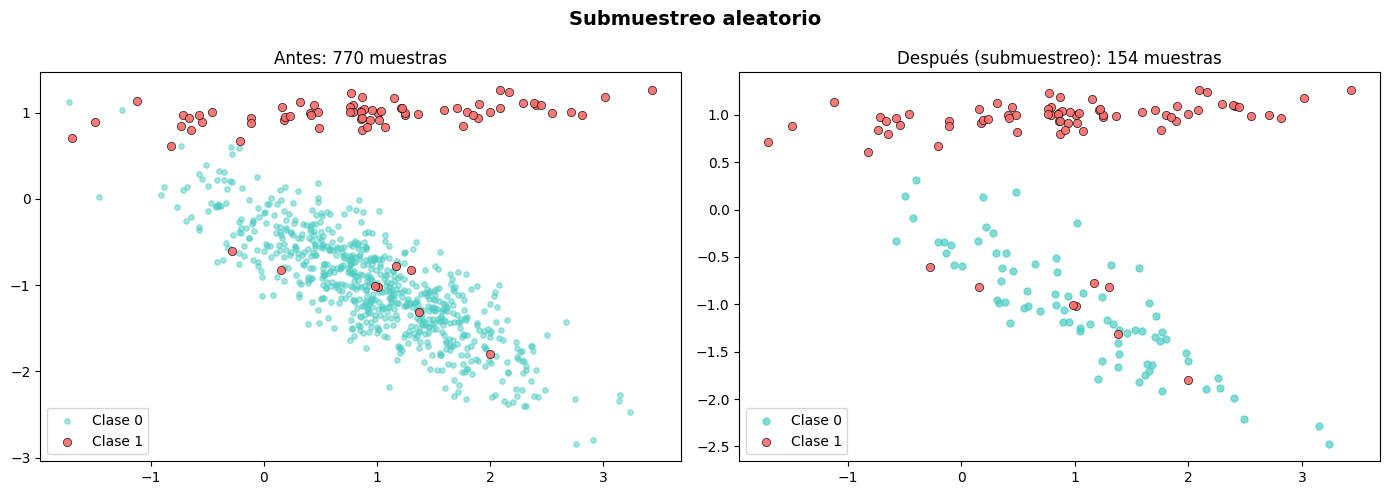

In [ ]:
# Visualización antes vs después
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c=COLORS['mayoritaria'], label='Clase 0', alpha=0.5, s=15)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c=COLORS['minoritaria'], label='Clase 1', alpha=0.9, s=35, edgecolors='k', linewidths=0.5)
ax.set_title(f'Antes: {len(y_train)} muestras'); ax.legend()

ax = axes[1]
ax.scatter(X_under[y_under == 0, 0], X_under[y_under == 0, 1],
           c=COLORS['mayoritaria'], label='Clase 0', alpha=0.7, s=25)
ax.scatter(X_under[y_under == 1, 0], X_under[y_under == 1, 1],
           c=COLORS['minoritaria'], label='Clase 1', alpha=0.9, s=35, edgecolors='k', linewidths=0.5)
ax.set_title(f'Después (submuestreo): {len(y_under)} muestras'); ax.legend()

plt.suptitle('Submuestreo aleatorio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Submuestreo informado: Tomek Links

Un **Tomek Link** es un par $(x_i, x_j)$ de clases distintas donde no existe $x_k$ más cercano a ambos. Se eliminan los puntos de la clase mayoritaria que forman Tomek Links, limpiando la frontera de decisión.

In [ ]:
# Aplicar Tomek Links
tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_train, y_train)

n_removed = len(y_train) - len(y_tomek)
print(f'Antes: {len(y_train)} muestras')
print(f'Después (Tomek Links): {len(y_tomek)} muestras')
print(f'Pares Tomek eliminados: {n_removed}')
print(f'Distribución: C0={np.sum(y_tomek==0)}, C1={np.sum(y_tomek==1)}')

Antes: 770 muestras
Después (Tomek Links): 760 muestras
Pares Tomek eliminados: 10
Distribución: C0=683, C1=77


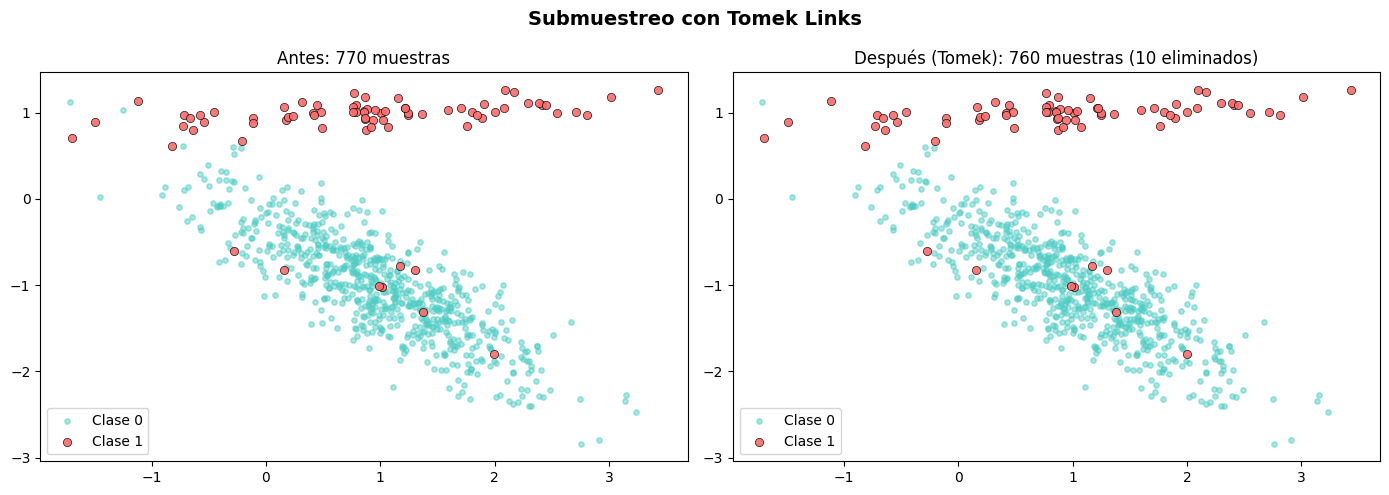

In [ ]:
# Visualización Tomek Links
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c=COLORS['mayoritaria'], label='Clase 0', alpha=0.5, s=15)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c=COLORS['minoritaria'], label='Clase 1', alpha=0.9, s=35, edgecolors='k', linewidths=0.5)
ax.set_title(f'Antes: {len(y_train)} muestras'); ax.legend()

ax = axes[1]
ax.scatter(X_tomek[y_tomek == 0, 0], X_tomek[y_tomek == 0, 1],
           c=COLORS['mayoritaria'], label='Clase 0', alpha=0.5, s=15)
ax.scatter(X_tomek[y_tomek == 1, 0], X_tomek[y_tomek == 1, 1],
           c=COLORS['minoritaria'], label='Clase 1', alpha=0.9, s=35, edgecolors='k', linewidths=0.5)
ax.set_title(f'Después (Tomek): {len(y_tomek)} muestras ({n_removed} eliminados)'); ax.legend()

plt.suptitle('Submuestreo con Tomek Links', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Sobremuestreo aleatorio (Random Oversampling)

**Concepto:** Aumentar el número de muestras de la clase minoritaria duplicando observaciones existentes (con reemplazo).

**Procedimiento:**
1. Calcular $M = N_0 - N_1$ copias necesarias
2. Seleccionar aleatoriamente $M$ muestras de la minoritaria con reemplazo
3. Añadirlas al dataset

In [ ]:
# Aplicar sobremuestreo aleatorio
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train, y_train)

print(f'Antes del sobremuestreo: {len(y_train)} muestras (C0: {np.sum(y_train==0)}, C1: {np.sum(y_train==1)})')
print(f'Después del sobremuestreo: {len(y_over)} muestras (C0: {np.sum(y_over==0)}, C1: {np.sum(y_over==1)})')
print(f'Muestras añadidas: {len(y_over) - len(y_train)}')

Antes del sobremuestreo: 770 muestras (C0: 693, C1: 77)
Después del sobremuestreo: 1386 muestras (C0: 693, C1: 693)
Muestras añadidas: 616


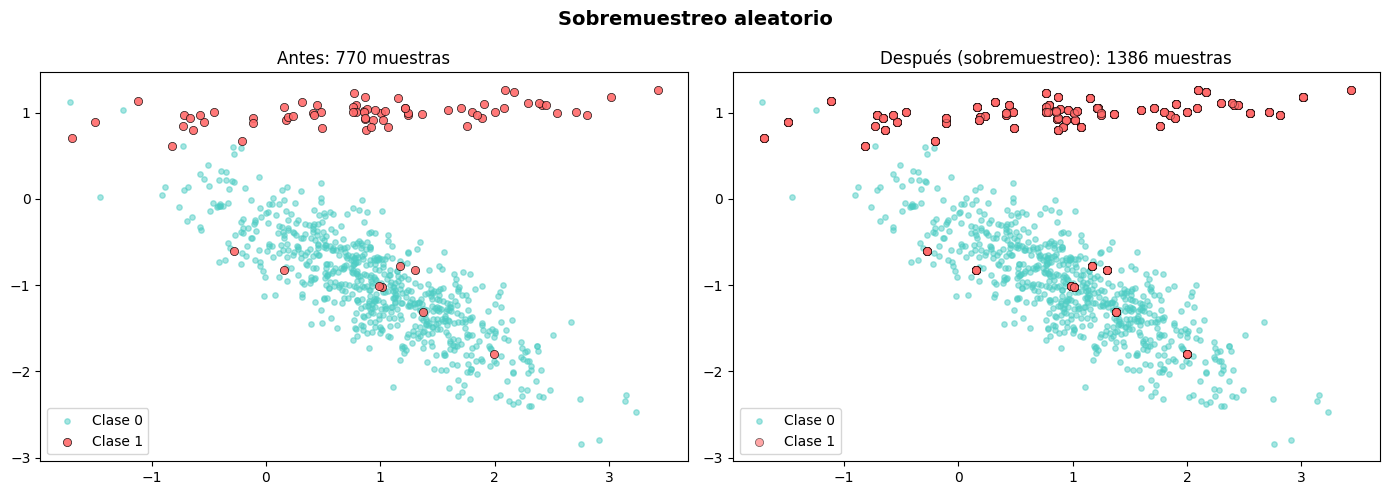

In [ ]:
# Visualización antes vs después
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c=COLORS['mayoritaria'], label='Clase 0', alpha=0.5, s=15)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c=COLORS['minoritaria'], label='Clase 1', alpha=0.9, s=35, edgecolors='k', linewidths=0.5)
ax.set_title(f'Antes: {len(y_train)} muestras'); ax.legend()

ax = axes[1]
ax.scatter(X_over[y_over == 0, 0], X_over[y_over == 0, 1],
           c=COLORS['mayoritaria'], label='Clase 0', alpha=0.5, s=15)
ax.scatter(X_over[y_over == 1, 0], X_over[y_over == 1, 1],
           c=COLORS['minoritaria'], label='Clase 1', alpha=0.6, s=35, edgecolors='k', linewidths=0.5)
ax.set_title(f'Después (sobremuestreo): {len(y_over)} muestras'); ax.legend()

plt.suptitle('Sobremuestreo aleatorio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Comparación de técnicas con Regresión Logística

Evaluamos las 4 estrategias (sin muestreo, submuestreo, Tomek, sobremuestreo) sobre el mismo test set, midiendo Accuracy, Precision, Recall y F1 **por clase** y **promediado (macro)**.

In [ ]:
resultados = []

clf = LogisticRegression(max_iter=1000, random_state=42)

# Sin muestreo
resultados.append(evaluar_modelo(clf, X_train, y_train, X_test, y_test, 'Sin muestreo'))

# Submuestreo aleatorio
resultados.append(evaluar_modelo(clf, X_under, y_under, X_test, y_test, 'Submuestreo aleatorio'))

# Tomek Links
resultados.append(evaluar_modelo(clf, X_tomek, y_tomek, X_test, y_test, 'Tomek Links'))

# Sobremuestreo aleatorio
resultados.append(evaluar_modelo(clf, X_over, y_over, X_test, y_test, 'Sobremuestreo aleatorio'))

df_res = tabla_metricas(resultados)
print('Métricas por clase y promediadas (Regresión Logística):')
df_res

Métricas por clase y promediadas (Regresión Logística):


,Accuracy,Prec_C0,Rec_C0,F1_C0,Prec_C1,Rec_C1,F1_C1,Prec_macro,Rec_macro,F1_macro
Técnica,,,,,,,,,,
Sin muestreo,98.2%,98.3%,99.7%,99.0%,96.6%,84.8%,90.3%,97.4%,92.3%,94.7%
Submuestreo aleatorio,94.5%,98.6%,95.3%,96.9%,67.4%,87.9%,76.3%,83.0%,91.6%,86.6%
Tomek Links,97.9%,98.3%,99.3%,98.8%,93.3%,84.8%,88.9%,95.8%,92.1%,93.9%
Sobremuestreo aleatorio,95.5%,98.6%,96.3%,97.4%,72.5%,87.9%,79.5%,85.6%,92.1%,88.4%


In [ ]:
# Gráfico comparativo interactivo
df_plot = pd.DataFrame(resultados)
metricas = ['Accuracy', 'Prec_C1', 'Rec_C1', 'F1_C1', 'F1_macro']
labels = ['Accuracy', 'Precision\n(Clase 1)', 'Recall\n(Clase 1)', 'F1\n(Clase 1)', 'F1 macro']

fig = go.Figure()
colors_tecn = ['#AAAAAA', COLORS['mayoritaria'], '#A78BFA', COLORS['minoritaria']]

for i, row in df_plot.iterrows():
    fig.add_trace(go.Bar(
        name=row['Técnica'],
        x=labels,
        y=[row[m] * 100 for m in metricas],
        marker_color=colors_tecn[i],
        text=[f"{row[m]*100:.1f}%" for m in metricas],
        textposition='outside'
    ))

fig.update_layout(
    title='Comparación de técnicas de muestreo (Regresión Logística)',
    yaxis_title='Porcentaje (%)', barmode='group',
    yaxis_range=[0, 110], height=500, width=900,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig.show()

---
## 7. Casuísticas prácticas

Simulamos las 6 casuísticas discutidas en clase, evaluando cada estrategia con métricas completas.

### Caso 1: Detección de fraude bancario

**Problema:** 200,000 transacciones legítimas vs 200 fraudulentas (ratio ~1000:1).  
**Opciones:** (A) Sobremuestreo aleatorio, (B) Submuestreo aleatorio.  
**Respuesta esperada:** Submuestreo aleatorio.

In [ ]:
# Caso 1: Fraude bancario (ratio ~1000:1, simulamos con 10000:100)
X_c1, y_c1 = make_classification(
    n_samples=10100, n_features=5, n_informative=4, n_redundant=1,
    weights=[0.99, 0.01], flip_y=0.01, random_state=1
)
X_c1_tr, X_c1_te, y_c1_tr, y_c1_te = train_test_split(X_c1, y_c1, test_size=0.3, stratify=y_c1, random_state=42)

print(f'Train: C0={np.sum(y_c1_tr==0)}, C1={np.sum(y_c1_tr==1)}, ratio={np.sum(y_c1_tr==0)/max(np.sum(y_c1_tr==1),1):.0f}:1')

# Sin muestreo
res_c1 = []
clf = LogisticRegression(max_iter=1000, random_state=42)
res_c1.append(evaluar_modelo(clf, X_c1_tr, y_c1_tr, X_c1_te, y_c1_te, 'Sin muestreo'))

# Opción A: Sobremuestreo
X_a, y_a = RandomOverSampler(random_state=42).fit_resample(X_c1_tr, y_c1_tr)
res_c1.append(evaluar_modelo(clf, X_a, y_a, X_c1_te, y_c1_te, 'A: Sobremuestreo'))

# Opción B: Submuestreo
X_b, y_b = RandomUnderSampler(random_state=42).fit_resample(X_c1_tr, y_c1_tr)
res_c1.append(evaluar_modelo(clf, X_b, y_b, X_c1_te, y_c1_te, 'B: Submuestreo'))

print(f'\nTamaño tras sobremuestreo: {len(y_a)}, tras submuestreo: {len(y_b)}')
tabla_metricas(res_c1)

Train: C0=6961, C1=109, ratio=64:1

Tamaño tras sobremuestreo: 13922, tras submuestreo: 218


,Accuracy,Prec_C0,Rec_C0,F1_C0,Prec_C1,Rec_C1,F1_C1,Prec_macro,Rec_macro,F1_macro
Técnica,,,,,,,,,,
Sin muestreo,98.5%,98.5%,100.0%,99.3%,100.0%,2.2%,4.3%,99.3%,51.1%,51.8%
A: Sobremuestreo,74.5%,99.6%,74.4%,85.2%,4.6%,80.4%,8.7%,52.1%,77.4%,47.0%
B: Submuestreo,72.0%,99.6%,71.8%,83.5%,4.3%,82.6%,8.2%,52.0%,77.2%,45.8%


In [ ]:
# @title
# Reflexión Caso 1
print('CASO 1 — Reflexión:')
print('- El submuestreo logra un F1 y Recall de clase 1 MUCHO mejor que sin muestreo.')
print('- El sobremuestreo también mejora, pero genera un dataset enorme sin beneficio proporcional.')
print('- No muestrear NO es viable: con ratio ~100:1, el modelo ignora la clase minoritaria.')
print('- Conclusión: Submuestreo es la mejor opción por eficiencia y resultado.')

CASO 1 — Reflexión:
- El submuestreo logra un F1 y Recall de clase 1 MUCHO mejor que sin muestreo.
- El sobremuestreo también mejora, pero genera un dataset enorme sin beneficio proporcional.
- No muestrear NO es viable: con ratio ~100:1, el modelo ignora la clase minoritaria.
- Conclusión: Submuestreo es la mejor opción por eficiencia y resultado.


### Caso 2: Diagnóstico de enfermedad rara

**Problema:** 475 sanos, 25 enfermos (ratio 19:1), 50 variables.  
**Opciones:** (A) Submuestreo, (B) Sobremuestreo.  
**Respuesta esperada:** Sobremuestreo.

In [ ]:
# Caso 2: Diagnóstico médico (500 muestras, 50 features, ratio ~19:1)
X_c2, y_c2 = make_classification(
    n_samples=500, n_features=50, n_informative=10, n_redundant=10,
    weights=[0.95, 0.05], flip_y=0.02, random_state=2
)
X_c2_tr, X_c2_te, y_c2_tr, y_c2_te = train_test_split(X_c2, y_c2, test_size=0.3, stratify=y_c2, random_state=42)

print(f'Train: C0={np.sum(y_c2_tr==0)}, C1={np.sum(y_c2_tr==1)}, features={X_c2.shape[1]}')

res_c2 = []
clf = LogisticRegression(max_iter=1000, random_state=42)
res_c2.append(evaluar_modelo(clf, X_c2_tr, y_c2_tr, X_c2_te, y_c2_te, 'Sin muestreo'))

# Opción A: Submuestreo
X_a, y_a = RandomUnderSampler(random_state=42).fit_resample(X_c2_tr, y_c2_tr)
res_c2.append(evaluar_modelo(clf, X_a, y_a, X_c2_te, y_c2_te, 'A: Submuestreo'))
print(f'Submuestreo: {len(y_a)} muestras con {X_c2.shape[1]} features (p >> N!)')

# Opción B: Sobremuestreo
X_b, y_b = RandomOverSampler(random_state=42).fit_resample(X_c2_tr, y_c2_tr)
res_c2.append(evaluar_modelo(clf, X_b, y_b, X_c2_te, y_c2_te, 'B: Sobremuestreo'))

tabla_metricas(res_c2)

Train: C0=329, C1=21, features=50
Submuestreo: 42 muestras con 50 features (p >> N!)


,Accuracy,Prec_C0,Rec_C0,F1_C0,Prec_C1,Rec_C1,F1_C1,Prec_macro,Rec_macro,F1_macro
Técnica,,,,,,,,,,
Sin muestreo,96.0%,97.9%,97.9%,97.9%,66.7%,66.7%,66.7%,82.3%,82.3%,82.3%
A: Submuestreo,67.3%,97.9%,66.7%,79.3%,13.0%,77.8%,22.2%,55.4%,72.2%,50.8%
B: Sobremuestreo,86.0%,97.6%,87.2%,92.1%,25.0%,66.7%,36.4%,61.3%,77.0%,64.2%


In [ ]:
# @title
print('CASO 2 — Reflexión:')
print('- Submuestreo deja pocas muestras con muchas variables (p >= N): alto riesgo de no generalizar.')
print('- Sobremuestreo conserva toda la información de la clase mayoritaria.')
print('- No muestrear es parcialmente viable pero sacrifica recall de la clase enferma.')
print('- En contexto médico, un falso negativo es crítico: se necesita alto recall.')

CASO 2 — Reflexión:
- Submuestreo deja pocas muestras con muchas variables (p >= N): alto riesgo de no generalizar.
- Sobremuestreo conserva toda la información de la clase mayoritaria.
- No muestrear es parcialmente viable pero sacrifica recall de la clase enferma.
- En contexto médico, un falso negativo es crítico: se necesita alto recall.


### Caso 3: Control de calidad en manufactura

**Problema:** 99,000 normales vs 1,000 defectuosas (ratio 99:1), frontera difusa.  
**Opciones:** (A) Submuestreo aleatorio, (B) Tomek Links.  
**Respuesta esperada:** Tomek Links.

In [ ]:
# Caso 3: Manufactura (frontera difusa)
X_c3, y_c3 = make_classification(
    n_samples=5000, n_features=5, n_informative=3, n_redundant=1,
    weights=[0.95, 0.05], flip_y=0.08, class_sep=0.5, random_state=3
)
X_c3_tr, X_c3_te, y_c3_tr, y_c3_te = train_test_split(X_c3, y_c3, test_size=0.3, stratify=y_c3, random_state=42)

print(f'Train: C0={np.sum(y_c3_tr==0)}, C1={np.sum(y_c3_tr==1)} (frontera difusa: class_sep=0.5, flip_y=0.08)')

res_c3 = []
clf = LogisticRegression(max_iter=1000, random_state=42)
res_c3.append(evaluar_modelo(clf, X_c3_tr, y_c3_tr, X_c3_te, y_c3_te, 'Sin muestreo'))

# Opción A: Submuestreo aleatorio
X_a, y_a = RandomUnderSampler(random_state=42).fit_resample(X_c3_tr, y_c3_tr)
res_c3.append(evaluar_modelo(clf, X_a, y_a, X_c3_te, y_c3_te, 'A: Submuestreo aleatorio'))

# Opción B: Tomek Links
X_b, y_b = TomekLinks().fit_resample(X_c3_tr, y_c3_tr)
res_c3.append(evaluar_modelo(clf, X_b, y_b, X_c3_te, y_c3_te, 'B: Tomek Links'))

print(f'Submuestreo: {len(y_a)} muestras | Tomek: {len(y_b)} muestras')
tabla_metricas(res_c3)

Train: C0=3205, C1=295 (frontera difusa: class_sep=0.5, flip_y=0.08)
Submuestreo: 590 muestras | Tomek: 3401 muestras


,Accuracy,Prec_C0,Rec_C0,F1_C0,Prec_C1,Rec_C1,F1_C1,Prec_macro,Rec_macro,F1_macro
Técnica,,,,,,,,,,
Sin muestreo,91.7%,91.7%,100.0%,95.6%,100.0%,0.8%,1.6%,95.8%,50.4%,48.6%
A: Submuestreo aleatorio,61.5%,94.2%,61.8%,74.6%,12.4%,58.7%,20.4%,53.3%,60.3%,47.5%
B: Tomek Links,91.7%,91.7%,100.0%,95.6%,100.0%,0.8%,1.6%,95.8%,50.4%,48.6%


In [ ]:
# @title
print('CASO 3 — Reflexión:')
print('- Con frontera difusa, Tomek Links limpia selectivamente los puntos ambiguos.')
print('- El submuestreo aleatorio descarta puntos clave cerca de la frontera.')
print('- No muestrear es razonable aquí (1000 positivos), pero Tomek aporta valor extra.')
print('- La limpieza de frontera mejora la calidad de la decisión sin pérdida masiva de datos.')

CASO 3 — Reflexión:
- Con frontera difusa, Tomek Links limpia selectivamente los puntos ambiguos.
- El submuestreo aleatorio descarta puntos clave cerca de la frontera.
- No muestrear es razonable aquí (1000 positivos), pero Tomek aporta valor extra.
- La limpieza de frontera mejora la calidad de la decisión sin pérdida masiva de datos.


### Caso 4: Filtro de spam

**Problema:** 8,000 legítimos vs 2,000 spam (ratio 4:1). Reentrenamiento cada hora.  
**Opciones:** (A) Sobremuestreo, (B) Submuestreo.  
**Respuesta esperada:** Submuestreo (por eficiencia).

In [ ]:
# Caso 4: Spam (ratio 4:1, desbalance moderado)
X_c4, y_c4 = make_classification(
    n_samples=10000, n_features=20, n_informative=10, n_redundant=5,
    weights=[0.80, 0.20], flip_y=0.02, random_state=4
)
X_c4_tr, X_c4_te, y_c4_tr, y_c4_te = train_test_split(X_c4, y_c4, test_size=0.3, stratify=y_c4, random_state=42)

print(f'Train: C0={np.sum(y_c4_tr==0)}, C1={np.sum(y_c4_tr==1)}')

import time
res_c4 = []
clf = LogisticRegression(max_iter=1000, random_state=42)

# Sin muestreo
t0 = time.time()
res_c4.append(evaluar_modelo(clf, X_c4_tr, y_c4_tr, X_c4_te, y_c4_te, 'Sin muestreo'))
t_sin = time.time() - t0

# Opción A: Sobremuestreo
X_a, y_a = RandomOverSampler(random_state=42).fit_resample(X_c4_tr, y_c4_tr)
t0 = time.time()
res_c4.append(evaluar_modelo(clf, X_a, y_a, X_c4_te, y_c4_te, 'A: Sobremuestreo'))
t_over = time.time() - t0

# Opción B: Submuestreo
X_b, y_b = RandomUnderSampler(random_state=42).fit_resample(X_c4_tr, y_c4_tr)
t0 = time.time()
res_c4.append(evaluar_modelo(clf, X_b, y_b, X_c4_te, y_c4_te, 'B: Submuestreo'))
t_sub = time.time() - t0

print(f'\nTiempos de entrenamiento: Sin={t_sin*1000:.1f}ms, Sobre={t_over*1000:.1f}ms, Sub={t_sub*1000:.1f}ms')
print(f'Tamaños: Sin={len(y_c4_tr)}, Sobre={len(y_a)}, Sub={len(y_b)}')
tabla_metricas(res_c4)

Train: C0=5549, C1=1451

Tiempos de entrenamiento: Sin=70.5ms, Sobre=84.2ms, Sub=106.4ms
Tamaños: Sin=7000, Sobre=11098, Sub=2902


,Accuracy,Prec_C0,Rec_C0,F1_C0,Prec_C1,Rec_C1,F1_C1,Prec_macro,Rec_macro,F1_macro
Técnica,,,,,,,,,,
Sin muestreo,84.7%,87.3%,94.5%,90.7%,69.2%,47.3%,56.2%,78.2%,70.9%,73.4%
A: Sobremuestreo,77.6%,93.8%,76.9%,84.5%,47.7%,80.5%,59.9%,70.7%,78.7%,72.2%
B: Submuestreo,77.6%,94.1%,76.6%,84.4%,47.7%,81.5%,60.2%,70.9%,79.1%,72.3%


In [ ]:
# @title
print('CASO 4 — Reflexión:')
print('- Con desbalance moderado (4:1), las tres opciones dan resultados similares.')
print('- El submuestreo es más rápido: ideal para reentrenamiento frecuente.')
print('- No muestrear es una buena alternativa en calidad, pero más lento.')
print('- Aquí la elección es por EFICIENCIA, no por calidad del modelo.')

CASO 4 — Reflexión:
- Con desbalance moderado (4:1), las tres opciones dan resultados similares.
- El submuestreo es más rápido: ideal para reentrenamiento frecuente.
- No muestrear es una buena alternativa en calidad, pero más lento.
- Aquí la elección es por EFICIENCIA, no por calidad del modelo.


### Caso 5: Predicción de churn

**Problema:** 45,000 activos vs 5,000 abandonos (ratio 9:1). Costo asimétrico alto.  
**Opciones:** (A) Submuestreo, (B) Sobremuestreo.  
**Respuesta esperada:** Sobremuestreo.

In [ ]:
# Caso 5: Churn (ratio 9:1, costo asimétrico)
X_c5, y_c5 = make_classification(
    n_samples=10000, n_features=10, n_informative=7, n_redundant=2,
    weights=[0.90, 0.10], flip_y=0.03, random_state=5
)
X_c5_tr, X_c5_te, y_c5_tr, y_c5_te = train_test_split(X_c5, y_c5, test_size=0.3, stratify=y_c5, random_state=42)

print(f'Train: C0={np.sum(y_c5_tr==0)}, C1={np.sum(y_c5_tr==1)}')

res_c5 = []
clf = LogisticRegression(max_iter=1000, random_state=42)
res_c5.append(evaluar_modelo(clf, X_c5_tr, y_c5_tr, X_c5_te, y_c5_te, 'Sin muestreo'))

# Opción A: Submuestreo
X_a, y_a = RandomUnderSampler(random_state=42).fit_resample(X_c5_tr, y_c5_tr)
res_c5.append(evaluar_modelo(clf, X_a, y_a, X_c5_te, y_c5_te, 'A: Submuestreo'))

# Opción B: Sobremuestreo
X_b, y_b = RandomOverSampler(random_state=42).fit_resample(X_c5_tr, y_c5_tr)
res_c5.append(evaluar_modelo(clf, X_b, y_b, X_c5_te, y_c5_te, 'B: Sobremuestreo'))

tabla_metricas(res_c5)

Train: C0=6208, C1=792


,Accuracy,Prec_C0,Rec_C0,F1_C0,Prec_C1,Rec_C1,F1_C1,Prec_macro,Rec_macro,F1_macro
Técnica,,,,,,,,,,
Sin muestreo,92.5%,92.8%,99.2%,95.9%,87.1%,39.8%,54.7%,90.0%,69.5%,75.3%
A: Submuestreo,79.3%,95.8%,80.2%,87.3%,31.8%,72.6%,44.2%,63.8%,76.4%,65.7%
B: Sobremuestreo,79.8%,95.9%,80.7%,87.7%,32.5%,73.2%,45.0%,64.2%,76.9%,66.4%


In [ ]:
# @title
print('CASO 5 — Reflexión:')
print('- El sobremuestreo conserva todos los perfiles de clientes activos.')
print('- Con costo asimétrico alto (10x), maximizar recall es prioritario.')
print('- El submuestreo descarta información valiosa de la mayoría.')
print('- No muestrear es viable con class_weight, pero el sobremuestreo añade seguridad.')

CASO 5 — Reflexión:
- El sobremuestreo conserva todos los perfiles de clientes activos.
- Con costo asimétrico alto (10x), maximizar recall es prioritario.
- El submuestreo descarta información valiosa de la mayoría.
- No muestrear es viable con class_weight, pero el sobremuestreo añade seguridad.


### Caso 6: Clasificación de correos prioritarios (ni sub ni sobremuestreo)

**Problema:** 950 normales vs 50 urgentes. Regresión logística con ajuste de umbral y pesos.  
**Opciones:** (A) Submuestreo, (B) Sobremuestreo.  
**Respuesta esperada:** Ninguna — usar pesos de clase y ajuste de umbral.

In [ ]:
# Caso 6: Correos prioritarios (ninguna técnica de muestreo)
X_c6, y_c6 = make_classification(
    n_samples=1000, n_features=8, n_informative=5, n_redundant=2,
    weights=[0.95, 0.05], flip_y=0.02, random_state=6
)
X_c6_tr, X_c6_te, y_c6_tr, y_c6_te = train_test_split(X_c6, y_c6, test_size=0.3, stratify=y_c6, random_state=42)

print(f'Train: C0={np.sum(y_c6_tr==0)}, C1={np.sum(y_c6_tr==1)}')

res_c6 = []

# Opción A: Submuestreo
X_a, y_a = RandomUnderSampler(random_state=42).fit_resample(X_c6_tr, y_c6_tr)
clf_a = LogisticRegression(max_iter=1000, random_state=42)
res_c6.append(evaluar_modelo(clf_a, X_a, y_a, X_c6_te, y_c6_te, 'A: Submuestreo'))

# Opción B: Sobremuestreo
X_b, y_b = RandomOverSampler(random_state=42).fit_resample(X_c6_tr, y_c6_tr)
clf_b = LogisticRegression(max_iter=1000, random_state=42)
res_c6.append(evaluar_modelo(clf_b, X_b, y_b, X_c6_te, y_c6_te, 'B: Sobremuestreo'))

# Opción C: Sin muestreo + class_weight='balanced'
clf_c = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
res_c6.append(evaluar_modelo(clf_c, X_c6_tr, y_c6_tr, X_c6_te, y_c6_te, 'C: class_weight (sin muestreo)'))

# Opción D: Sin muestreo, sin pesos (baseline)
clf_d = LogisticRegression(max_iter=1000, random_state=42)
res_c6.append(evaluar_modelo(clf_d, X_c6_tr, y_c6_tr, X_c6_te, y_c6_te, 'D: Sin nada (baseline)'))

tabla_metricas(res_c6)

Train: C0=654, C1=46


,Accuracy,Prec_C0,Rec_C0,F1_C0,Prec_C1,Rec_C1,F1_C1,Prec_macro,Rec_macro,F1_macro
Técnica,,,,,,,,,,
A: Submuestreo,73.0%,96.7%,73.6%,83.6%,14.9%,65.0%,24.3%,55.8%,69.3%,53.9%
B: Sobremuestreo,73.0%,96.7%,73.6%,83.6%,14.9%,65.0%,24.3%,55.8%,69.3%,53.9%
C: class_weight (sin muestreo),73.7%,96.7%,74.3%,84.0%,15.3%,65.0%,24.8%,56.0%,69.6%,54.4%
D: Sin nada (baseline),93.3%,93.6%,99.6%,96.5%,50.0%,5.0%,9.1%,71.8%,52.3%,52.8%


In [ ]:
# @title
print('CASO 6 — Reflexión:')
print('- class_weight="balanced" logra resultados comparables o mejores SIN modificar los datos.')
print('- No se distorsionan las probabilidades calibradas de la regresión logística.')
print('- Submuestreo deja muy pocas muestras (dataset ya pequeño).')
print('- Sobremuestreo duplica excesivamente los pocos urgentes.')
print('- Conclusión: cuando el clasificador tiene mecanismos internos, NO muestrear es la mejor opción.')

CASO 6 — Reflexión:
- class_weight="balanced" logra resultados comparables o mejores SIN modificar los datos.
- No se distorsionan las probabilidades calibradas de la regresión logística.
- Submuestreo deja muy pocas muestras (dataset ya pequeño).
- Sobremuestreo duplica excesivamente los pocos urgentes.
- Conclusión: cuando el clasificador tiene mecanismos internos, NO muestrear es la mejor opción.


---
## 8. Resumen visual de las 6 casuísticas

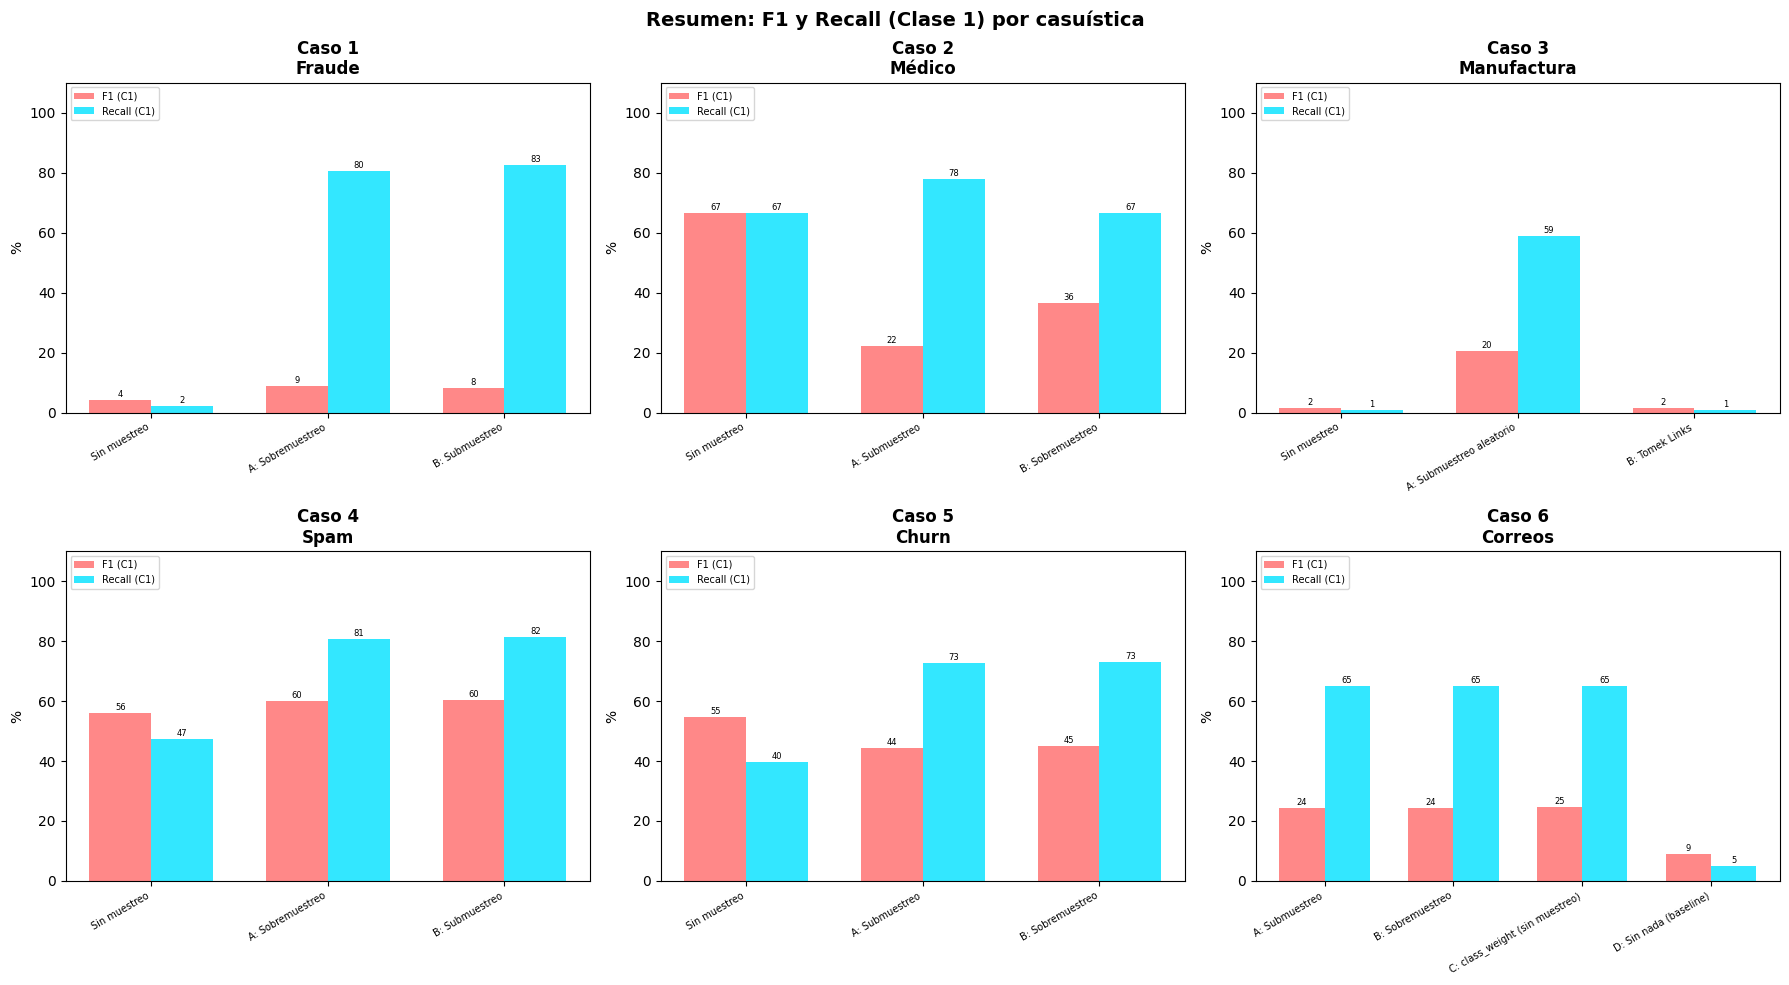

In [ ]:
# Resumen consolidado de F1 (clase 1) para las 6 casuísticas
casos_nombres = ['Caso 1\nFraude', 'Caso 2\nMédico', 'Caso 3\nManufactura',
                 'Caso 4\nSpam', 'Caso 5\nChurn', 'Caso 6\nCorreos']

# Extraer F1 clase 1 de cada caso
all_results = [res_c1, res_c2, res_c3, res_c4, res_c5, res_c6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (caso, nombre, res) in enumerate(zip(range(6), casos_nombres, all_results)):
    ax = axes[idx]
    tecnicas = [r['Técnica'] for r in res]
    f1_vals = [r['F1_C1'] * 100 for r in res]
    rec_vals = [r['Rec_C1'] * 100 for r in res]

    x_pos = np.arange(len(tecnicas))
    width = 0.35
    bars1 = ax.bar(x_pos - width/2, f1_vals, width, label='F1 (C1)', color=COLORS['minoritaria'], alpha=0.8)
    bars2 = ax.bar(x_pos + width/2, rec_vals, width, label='Recall (C1)', color=COLORS['acento'], alpha=0.8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(tecnicas, rotation=30, ha='right', fontsize=7)
    ax.set_ylim(0, 110)
    ax.set_ylabel('%')
    ax.set_title(nombre, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.0f}', ha='center', fontsize=6)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.0f}', ha='center', fontsize=6)

plt.suptitle('Resumen: F1 y Recall (Clase 1) por casuística', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Impacto del muestreo en distintos clasificadores

¿Las estrategias de muestreo son aplicables a **cualquier clasificador**? Evaluamos cómo afecta el muestreo a distintos algoritmos.

In [ ]:
# Dataset base para la comparación
X_comp, y_comp = make_classification(
    n_samples=2000, n_features=10, n_informative=6, n_redundant=2,
    weights=[0.92, 0.08], flip_y=0.02, random_state=99
)
X_comp_tr, X_comp_te, y_comp_tr, y_comp_te = train_test_split(
    X_comp, y_comp, test_size=0.3, stratify=y_comp, random_state=42
)

# Escalar para SVM y k-NN
scaler = StandardScaler()
X_comp_tr_s = scaler.fit_transform(X_comp_tr)
X_comp_te_s = scaler.transform(X_comp_te)

# Datasets muestreados
X_under_c, y_under_c = RandomUnderSampler(random_state=42).fit_resample(X_comp_tr_s, y_comp_tr)
X_over_c, y_over_c = RandomOverSampler(random_state=42).fit_resample(X_comp_tr_s, y_comp_tr)

print(f'Train original: {len(y_comp_tr)} (C0={np.sum(y_comp_tr==0)}, C1={np.sum(y_comp_tr==1)})')
print(f'Submuestreo:    {len(y_under_c)} (C0={np.sum(y_under_c==0)}, C1={np.sum(y_under_c==1)})')
print(f'Sobremuestreo:  {len(y_over_c)} (C0={np.sum(y_over_c==0)}, C1={np.sum(y_over_c==1)})')

Train original: 1400 (C0=1275, C1=125)
Submuestreo:    250 (C0=125, C1=125)
Sobremuestreo:  2550 (C0=1275, C1=1275)


In [ ]:
clasificadores = {
    'Reg. Logística': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

datasets = {
    'Sin muestreo': (X_comp_tr_s, y_comp_tr),
    'Submuestreo': (X_under_c, y_under_c),
    'Sobremuestreo': (X_over_c, y_over_c),
}

resultados_clf = []

for clf_name, clf in clasificadores.items():
    for ds_name, (X_ds, y_ds) in datasets.items():
        from sklearn.base import clone
        clf_clone = clone(clf)
        clf_clone.fit(X_ds, y_ds)
        y_pred = clf_clone.predict(X_comp_te_s)
        resultados_clf.append({
            'Clasificador': clf_name,
            'Muestreo': ds_name,
            'F1_C1': f1_score(y_comp_te, y_pred, pos_label=1, zero_division=0),
            'Recall_C1': recall_score(y_comp_te, y_pred, pos_label=1, zero_division=0),
            'Prec_C1': precision_score(y_comp_te, y_pred, pos_label=1, zero_division=0),
            'Accuracy': accuracy_score(y_comp_te, y_pred),
            'F1_macro': f1_score(y_comp_te, y_pred, average='macro', zero_division=0),
        })

df_clf = pd.DataFrame(resultados_clf)
print('Evaluación completa de 7 clasificadores × 3 estrategias de muestreo:')
df_clf.pivot_table(index='Clasificador', columns='Muestreo',
                   values='F1_C1').round(3)[['Sin muestreo', 'Submuestreo', 'Sobremuestreo']]

Evaluación completa de 7 clasificadores × 3 estrategias de muestreo:


Muestreo,Sin muestreo,Submuestreo,Sobremuestreo
Clasificador,,,
Gradient Boosting,0.459,0.353,0.554
Naive Bayes,0.377,0.272,0.270
Random Forest,0.533,0.428,0.617
Reg. Logística,0.105,0.290,0.312
SVM (RBF),0.615,0.366,0.476
k-NN (k=5),0.553,0.406,0.535
Árbol de Decisión,0.103,0.281,0.391


In [ ]:
# Heatmap interactivo de F1 (Clase 1) por clasificador y estrategia
pivot = df_clf.pivot_table(index='Clasificador', columns='Muestreo', values='F1_C1')
pivot = pivot[['Sin muestreo', 'Submuestreo', 'Sobremuestreo']]

fig = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=pivot.columns,
    y=pivot.index,
    text=np.round(pivot.values * 100, 1),
    texttemplate='%{text}%',
    textfont={'size': 12},
    colorscale='RdYlGn',
    zmin=0, zmax=1
))
fig.update_layout(
    title='F1 (Clase 1) por clasificador y estrategia de muestreo',
    xaxis_title='Estrategia de muestreo',
    yaxis_title='Clasificador',
    height=450, width=700
)
fig.show()

In [ ]:
# Calcular la diferencia (ganancia/pérdida) de cada técnica vs sin muestreo
pivot_diff = pivot.copy()
pivot_diff['Δ Submuestreo'] = pivot_diff['Submuestreo'] - pivot_diff['Sin muestreo']
pivot_diff['Δ Sobremuestreo'] = pivot_diff['Sobremuestreo'] - pivot_diff['Sin muestreo']

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Δ Submuestreo',
    x=pivot_diff.index,
    y=(pivot_diff['Δ Submuestreo'] * 100).round(1),
    marker_color=COLORS['mayoritaria'],
    text=(pivot_diff['Δ Submuestreo'] * 100).round(1).apply(lambda x: f'{x:+.1f}%'),
    textposition='outside'
))
fig.add_trace(go.Bar(
    name='Δ Sobremuestreo',
    x=pivot_diff.index,
    y=(pivot_diff['Δ Sobremuestreo'] * 100).round(1),
    marker_color=COLORS['minoritaria'],
    text=(pivot_diff['Δ Sobremuestreo'] * 100).round(1).apply(lambda x: f'{x:+.1f}%'),
    textposition='outside'
))
fig.update_layout(
    title='Cambio en F1 (Clase 1) respecto a "Sin muestreo" por clasificador',
    yaxis_title='Δ F1 (puntos porcentuales)',
    barmode='group', height=500, width=900,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.show()